# Customer Churn Prediction

Predicting customer churn using machine learning

## Project Overview

Customer churn is an important business problem for subscription-based companies. Identifying customers who are likely to leave can help organizations prioritize retention efforts and allocate resources more effectively.

In this project, a machine learning model is developed to predict customer churn using the IBM Telco Customer Churn dataset.

The project follows an end-to-end workflow including exploratory data analysis, data preprocessing, model development, model comparison, threshold optimization, model interpretation, and business recommendations.

## Objective

The main objective of this project is to develop a classification model capable of identifying customers who are at higher risk of churn.

Because missing a potential churner can represent a lost retention opportunity, the analysis places particular emphasis on **Recall**, while also considering Precision, F1-score, ROC-AUC, and Average Precision.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading and Initial Inspection

In [2]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Data Cleaning

The `TotalCharges` column contains blank values stored as strings. These values are converted to numeric format, with invalid entries represented as missing values.

Since these observations correspond to customers with no accumulated charges, missing values are replaced with `0`.

### Target Variable

The target variable `Churn` is converted from categorical values (`Yes` / `No`) into a binary format:

- `1` → Customer churned
- `0` → Customer remained

In [7]:
df[df["TotalCharges"].str.strip() == ""]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [8]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [9]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

df["TotalCharges"].isnull().sum()


np.int64(0)

## Exploratory Data Analysis

Before developing the predictive models, the dataset is explored to identify patterns and relationships associated with customer churn.

In [10]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [11]:
churn_by_contract = (
    pd.crosstab(
        df["Contract"],
        df["Churn"],
        normalize="index"
    ) * 100
)

churn_by_contract

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


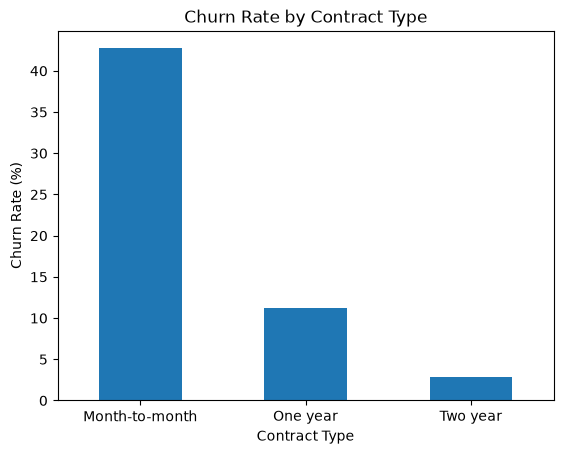

In [12]:
churn_by_contract["Yes"].plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

### Contract Type and Churn

Month-to-month customers show substantially higher churn rates than customers with one-year or two-year contracts.

### Customer Tenure

In [13]:
tenure_groups = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-12", "13-24", "25-48", "49-72"]
)

tenure_groups.value_counts().sort_index()

tenure
0-12     2186
13-24    1024
25-48    1594
49-72    2239
Name: count, dtype: int64

In [14]:
churn_by_tenure = (
    pd.crosstab(
        tenure_groups,
        df["Churn"],
        normalize="index"
    ) * 100
)

churn_by_tenure

Churn,No,Yes
tenure,,
0-12,52.561757,47.438243
13-24,71.289062,28.710938
25-48,79.611041,20.388959
49-72,90.486824,9.513176


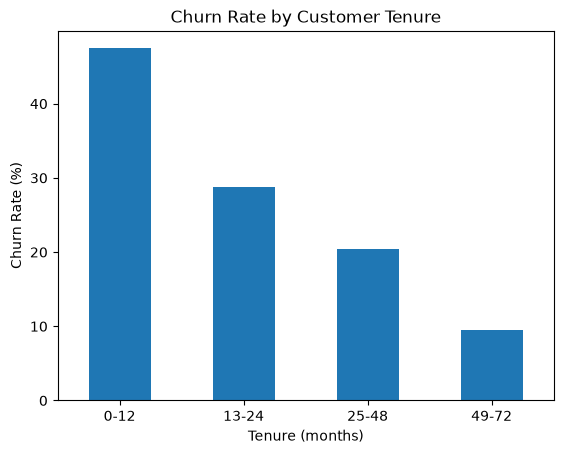

In [15]:
churn_by_tenure["Yes"].plot(kind="bar")

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure (months)")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

### Customer Tenure and Churn

Churn is highest among customers with shorter tenure and generally decreases as the customer relationship becomes longer.

## Multivariate Analysis

In [16]:
churn_by_contract_tenure = (
    pd.crosstab(
        [tenure_groups, df["Contract"]],
        df["Churn"],
        normalize="index"
    ) * 100
)

churn_by_contract_tenure

Churn                          No        Yes
tenure Contract                             
0-12   Month-to-month   48.645938  51.354062
       One year         89.516129  10.483871
       Two year        100.000000   0.000000
13-24  Month-to-month   62.279512  37.720488
       One year         91.878173   8.121827
       Two year        100.000000   0.000000
25-48  Month-to-month   67.082294  32.917706
       One year         89.382239  10.617761
       Two year         97.810219   2.189781
49-72  Month-to-month   73.976608  26.023392
       One year         87.066246  12.933754
       Two year         96.674584   3.325416

In [17]:
charge_groups = pd.qcut(
    df["MonthlyCharges"],
    q=4,
    labels=["Q1 - Low", "Q2", "Q3", "Q4 - High"]
)

churn_by_charges = (
    pd.crosstab(
        charge_groups,
        df["Churn"],
        normalize="index"
    ) * 100
)

churn_by_charges

Churn,No,Yes
MonthlyCharges,,
Q1 - Low,88.762770,11.237230
Q2,75.424689,24.575311
Q3,62.492886,37.507114
Q4 - High,67.121729,32.878271


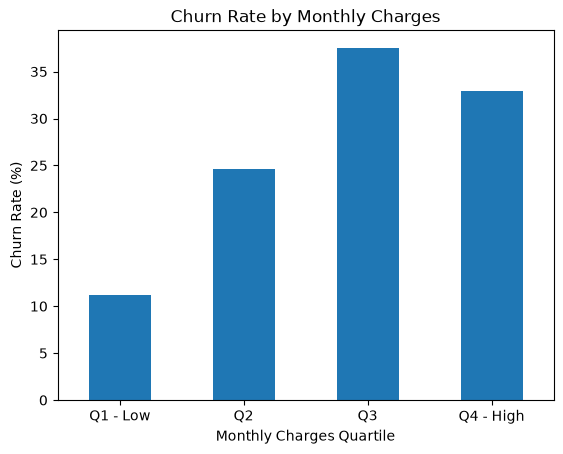

In [18]:
churn_by_charges["Yes"].plot(kind="bar")

plt.title("Churn Rate by Monthly Charges")
plt.xlabel("Monthly Charges Quartile")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

### Internet Service

In [19]:
churn_by_internet = (
    pd.crosstab(
        df["InternetService"],
        df["Churn"],
        normalize="index"
    ) * 100
)

churn_by_internet

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


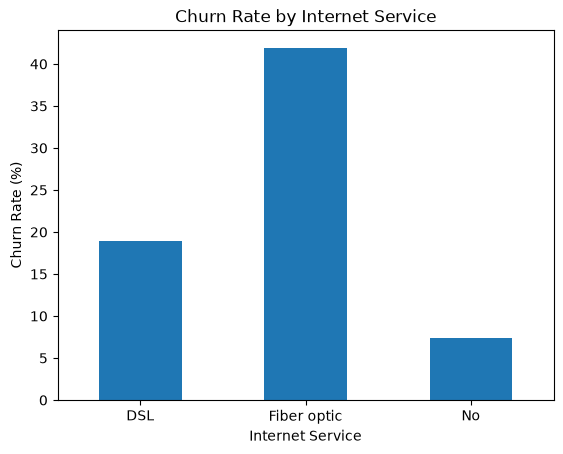

In [20]:
churn_by_internet["Yes"].plot(kind="bar")

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [21]:
df.groupby("InternetService")["MonthlyCharges"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
InternetService,,,,,
DSL,2421,58.102169,56.150,23.45,94.80
Fiber optic,3096,91.500129,91.675,67.75,118.75
No,1526,21.079194,20.150,18.25,26.90


In [22]:
churn_by_internet_contract = (
    pd.crosstab(
        [df["InternetService"], df["Contract"]],
        df["Churn"],
        normalize="index"
    ) * 100
)

churn_by_internet_contract

Churn                                  No        Yes
InternetService Contract                            
DSL             Month-to-month  67.784137  32.215863
                One year        90.701754   9.298246
                Two year        98.089172   1.910828
Fiber optic     Month-to-month  45.394737  54.605263
                One year        80.705009  19.294991
                Two year        92.773893   7.226107
No              Month-to-month  81.106870  18.893130
                One year        97.527473   2.472527
                Two year        99.216301   0.783699

## Key Findings

### 1. Overall churn
26.5% of customers churned, while 73.5% remained with the company.

### 2. Contract type
Month-to-month customers show substantially higher churn than customers with one-year or two-year contracts.

### 3. Customer tenure
Churn decreases as customer tenure increases. Customers with 0-12 months of tenure show the highest churn rate.

### 4. Monthly charges
Churn does not increase linearly with monthly charges. The highest churn rate is observed in the third monthly-charge quartile.

### 5. Internet service
Fiber optic customers show substantially higher churn than DSL and customers without internet service.

### 6. Interaction between variables
The association between Contract and Churn remains strong across different tenure groups. Similarly, Fiber optic customers show higher churn than DSL customers even when comparing customers within the same contract type.

### Important note
These findings describe associations observed in the data and should not be interpreted as causal relationships.

## EDA Summary

The exploratory analysis identified several patterns associated with customer churn.

The main findings were:

- **Month-to-month contracts** are associated with substantially higher churn.
- **Shorter customer tenure** is associated with higher churn, particularly during the first months of the customer relationship.
- **Fiber optic customers** show higher churn rates than DSL customers.
- Monthly charges show a more complex relationship with churn rather than a simple linear pattern.
- The combination of **contract type, tenure, and internet service** provides additional evidence of differences in churn risk across customer segments.

These findings provide the business context for the predictive modeling stage. The next step is to prepare the dataset and evaluate whether these patterns can be used to predict customer churn.

## Data preprocessing

### Feature Selection and Target Definition

The `customerID` column is excluded because it is a unique identifier and does not provide meaningful predictive information.

The target variable is `Churn`, which will be encoded as a binary variable:

- `Yes` → 1
- `No` → 0

The remaining features are separated into numerical and categorical variables according to their data type and meaning.

In [23]:
# Define the target variable
y = df["Churn"].map({"Yes": 1, "No": 0})

# Define the feature matrix
X = df.drop(columns=["customerID", "Churn"])

# Define numerical and categorical features
numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

In [24]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nNumerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

print("\nTarget distribution:")
print(y.value_counts())

X shape: (7043, 19)
y shape: (7043,)

Numerical features: 4
Categorical features: 15

Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


### Train/Test Split

The dataset is divided into training and test sets using a stratified split.

Stratification is used to preserve the proportion of churned and non-churned customers in both subsets.

The **test set is kept untouched until the final model evaluation**.

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [26]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

X_train shape: (5634, 19)
X_test shape: (1409, 19)

Training target distribution:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Test target distribution:
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


### Preprocessing

The dataset contains both numerical and categorical variables, so different preprocessing strategies are required.

- Numerical features are standardized using `StandardScaler`.
- Categorical features are transformed using `OneHotEncoder`.
- `handle_unknown="ignore"` is used to ensure that previously unseen categories do not cause errors during prediction.

These transformations are combined using a `ColumnTransformer`.

In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [28]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

## Baseline Model — Logistic Regression

Logistic Regression is used as the baseline model because it provides a simple and interpretable reference for the classification problem.

It also allows us to examine the direction and relative importance of the model coefficients, which will be useful later when interpreting the results from a business perspective.

The preprocessing steps and the model are combined into a single pipeline to prevent data leakage and ensure that the same transformations are applied consistently to training and unseen data.

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [30]:
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

### Model Training

The baseline model is fitted using the training data.

In [31]:
baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [32]:
y_pred = baseline_model.predict(X_test)

In [33]:
y_pred_proba = baseline_model.predict_proba(X_test)[:, 1]

### Baseline Evaluation

The baseline model is evaluated using several classification metrics.

Because the dataset is imbalanced and the business objective is to identify customers at risk of churn, accuracy alone is not sufficient.

Therefore, the evaluation includes:

- Precision
- Recall
- F1-score
- ROC-AUC

In [34]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba):.4f}")

Accuracy:  0.8055
Precision: 0.6572
Recall:    0.5588
F1 Score:  0.6040
ROC-AUC:   0.8421


### Confusion Matrix

The confusion matrix provides a detailed view of correct and incorrect churn predictions.

It allows us to distinguish between:
- True Negatives: correctly predicted non-churn customers.
- False Positives: customers predicted to churn who actually stayed.
- False Negatives: customers predicted not to churn who actually churned.
- True Positives: correctly predicted churn customers.

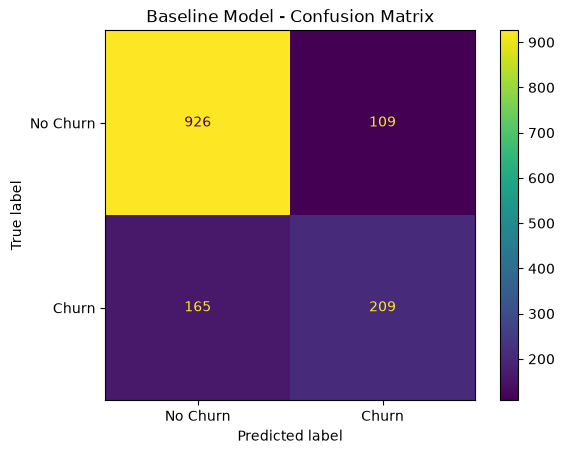

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Baseline Model - Confusion Matrix")
plt.show()

### Classification Report

The classification report provides precision, recall, and F1-score for each class, allowing us to evaluate the model's performance for both churn and non-churn customers.

In [36]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["No Churn", "Churn"]
))

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



## Threshold Optimization

By default, binary classification models use a probability threshold of 0.50 to convert predicted probabilities into class labels.

However, the optimal threshold depends on the business objective.

In this project, missing a customer who is likely to churn represents a potential lost retention opportunity. Therefore, we investigate whether adjusting the classification threshold can improve the balance between Precision and Recall.

The threshold is selected using a separate validation set, while the test set remains untouched until the final evaluation.

### Threshold Analysis

The default classification threshold of 0.50 is not necessarily optimal for a churn prediction problem.

We evaluate how different thresholds affect precision, recall, and F1-score in order to understand the trade-off between detecting more churn customers and generating false positives.

### Threshold Selection

The classification threshold is selected using the validation set rather than the test set.

The validation set is used to evaluate different thresholds and select the one that provides the best F1-score. The test set remains untouched until the final model evaluation.


In [37]:
X_train_model, X_val, y_train_model, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

In [38]:
print("X_train_model shape:", X_train_model.shape)
print("X_val shape:", X_val.shape)

print("\nTraining target distribution:")
print(y_train_model.value_counts(normalize=True))

print("\nValidation target distribution:")
print(y_val.value_counts(normalize=True))

X_train_model shape: (4507, 19)
X_val shape: (1127, 19)

Training target distribution:
Churn
0    0.734635
1    0.265365
Name: proportion, dtype: float64

Validation target distribution:
Churn
0    0.734694
1    0.265306
Name: proportion, dtype: float64


### Validation Model

A separate model is trained using only the training subset. The validation set is used to evaluate different classification thresholds without influencing the final test evaluation.

In [39]:
validation_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

In [40]:
validation_model.fit(X_train_model, y_train_model)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [41]:
y_val_proba = validation_model.predict_proba(X_val)[:, 1]

In [42]:
print("Validation probabilities:", y_val_proba.shape)
print("Minimum probability:", y_val_proba.min())
print("Maximum probability:", y_val_proba.max())

Validation probabilities: (1127,)
Minimum probability: 0.0016411844450505966
Maximum probability: 0.8403148496206848


In [43]:
thresholds = np.arange(0.20, 0.61, 0.05)

validation_results = []

for threshold in thresholds:
    predictions = (y_val_proba >= threshold).astype(int)

    validation_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_val, predictions),
        "Recall": recall_score(y_val, predictions),
        "F1": f1_score(y_val, predictions)
    })

validation_results

[{'Threshold': np.float64(0.2),
  'Precision': 0.46545454545454545,
  'Recall': 0.8561872909698997,
  'F1': 0.6030624263839811},
 {'Threshold': np.float64(0.25),
  'Precision': 0.511727078891258,
  'Recall': 0.802675585284281,
  'F1': 0.625},
 {'Threshold': np.float64(0.3),
  'Precision': 0.5445783132530121,
  'Recall': 0.7558528428093646,
  'F1': 0.6330532212885154},
 {'Threshold': np.float64(0.35),
  'Precision': 0.5792349726775956,
  'Recall': 0.7090301003344481,
  'F1': 0.637593984962406},
 {'Threshold': np.float64(0.39999999999999997),
  'Precision': 0.6172839506172839,
  'Recall': 0.6688963210702341,
  'F1': 0.6420545746388443},
 {'Threshold': np.float64(0.44999999999999996),
  'Precision': 0.6593406593406593,
  'Recall': 0.6020066889632107,
  'F1': 0.6293706293706294},
 {'Threshold': np.float64(0.49999999999999994),
  'Precision': 0.6936170212765957,
  'Recall': 0.5451505016722408,
  'F1': 0.6104868913857678},
 {'Threshold': np.float64(0.5499999999999999),
  'Precision': 0.73170

### Precision-Recall Trade-off

Precision and recall change as the classification threshold is adjusted.

Lower thresholds increase the number of customers classified as potential churners, improving recall at the expense of precision.

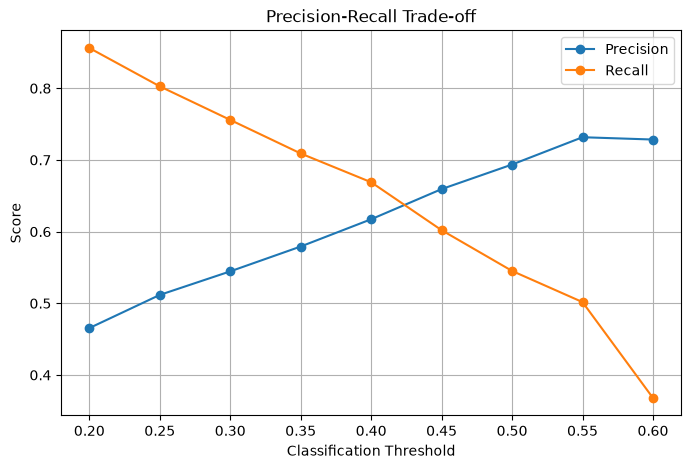

In [44]:
import matplotlib.pyplot as plt

threshold_values = [r["Threshold"] for r in validation_results]
precision_values = [r["Precision"] for r in validation_results]
recall_values = [r["Recall"] for r in validation_results]

plt.figure(figsize=(8, 5))

plt.plot(threshold_values, precision_values, marker="o", label="Precision")
plt.plot(threshold_values, recall_values, marker="o", label="Recall")

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Trade-off")
plt.legend()
plt.grid(True)
plt.show()

In [45]:
thresholds_fine = np.arange(0.20, 0.61, 0.01)

fine_results = []

for threshold in thresholds_fine:
    predictions = (y_val_proba >= threshold).astype(int)

    fine_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_val, predictions),
        "Recall": recall_score(y_val, predictions),
        "F1": f1_score(y_val, predictions)
    })

In [46]:
best_result = max(fine_results, key=lambda x: x["F1"])

best_result

{'Threshold': np.float64(0.38000000000000017),
 'Precision': 0.6076696165191741,
 'Recall': 0.6889632107023411,
 'F1': 0.64576802507837}

## Model Comparison

To determine whether a non-linear model could capture additional patterns in the data, Random Forest was evaluated against the Logistic Regression baseline.

In [47]:
from sklearn.ensemble import RandomForestClassifier

In [48]:
from sklearn.base import clone

In [49]:
rf_model = Pipeline([
    ("preprocessor", clone(baseline_model.named_steps["preprocessor"])),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ))
])

In [50]:
rf_model.fit(X_train_model, y_train_model)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [51]:
rf_val_proba = rf_model.predict_proba(X_val)[:, 1]

In [52]:
rf_val_pred = (rf_val_proba >= 0.50).astype(int)

In [53]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

rf_accuracy = accuracy_score(y_val, rf_val_pred)
rf_precision = precision_score(y_val, rf_val_pred)
rf_recall = recall_score(y_val, rf_val_pred)
rf_f1 = f1_score(y_val, rf_val_pred)
rf_roc_auc = roc_auc_score(y_val, rf_val_proba)

print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1 Score:  {rf_f1:.4f}")
print(f"ROC-AUC:   {rf_roc_auc:.4f}")

Accuracy:  0.7791
Precision: 0.5744
Recall:    0.6455
F1 Score:  0.6079
ROC-AUC:   0.8265


In [54]:
# Logistic Regression using the optimized threshold
y_val_pred_lr = (y_val_proba >= best_result["Threshold"]).astype(int)

# Random Forest using the default threshold
y_val_pred_rf = rf_val_pred

In [55]:
from sklearn.metrics import confusion_matrix

cm_model1 = confusion_matrix(y_val, y_val_pred_lr)
cm_model2 = confusion_matrix(y_val, y_val_pred_rf)

print("Matriz de confusión - Modelo 1")
print(cm_model1)

print("\nMatriz de confusión - Modelo 2")
print(cm_model2)

Matriz de confusión - Modelo 1
[[695 133]
 [ 93 206]]

Matriz de confusión - Modelo 2
[[685 143]
 [106 193]]


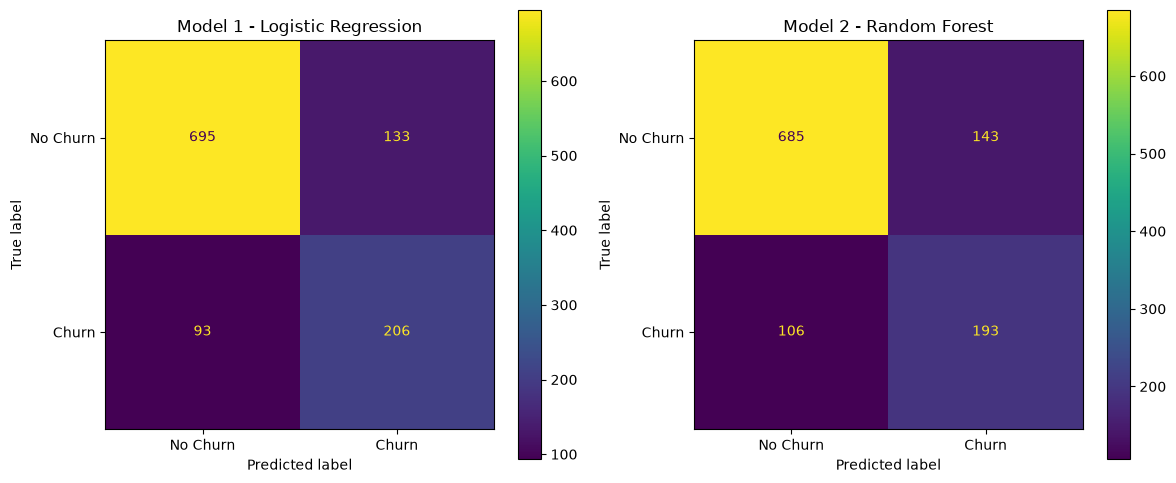

In [56]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# LR
ConfusionMatrixDisplay(
    confusion_matrix=cm_model1,
    display_labels=["No Churn", "Churn"]
).plot(ax=axes[0], values_format="d")

axes[0].set_title("Model 1 - Logistic Regression")

# RF
ConfusionMatrixDisplay(
    confusion_matrix=cm_model2,
    display_labels=["No Churn", "Churn"]
).plot(ax=axes[1], values_format="d")

axes[1].set_title("Model 2 - Random Forest")

plt.tight_layout()
plt.show()

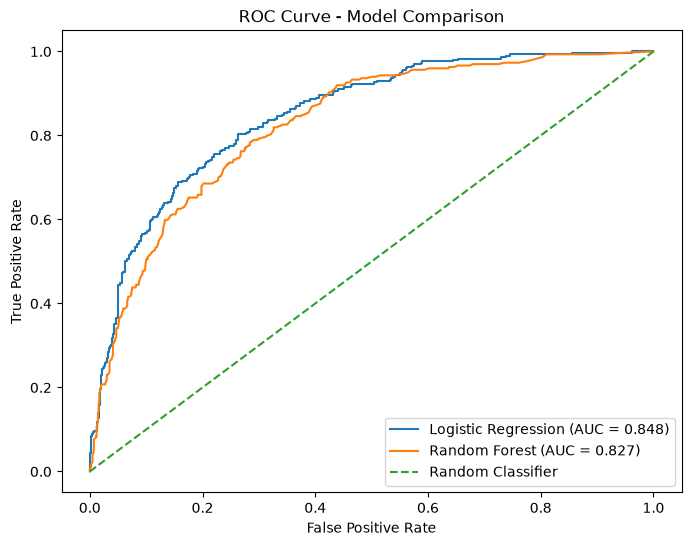

In [57]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Curv ROC - LR
fpr_model1, tpr_model1, _ = roc_curve(y_val, y_val_proba)
auc_model1 = roc_auc_score(y_val, y_val_proba)

# Curv ROC - RF
fpr_model2, tpr_model2, _ = roc_curve(y_val, rf_val_proba)
auc_model2 = roc_auc_score(y_val, rf_val_proba)

# Graffic
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_model1,
    tpr_model1,
    label=f"Logistic Regression (AUC = {auc_model1:.3f})"
)

plt.plot(
    fpr_model2,
    tpr_model2,
    label=f"Random Forest (AUC = {auc_model2:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Model Comparison")
plt.legend()
plt.show()

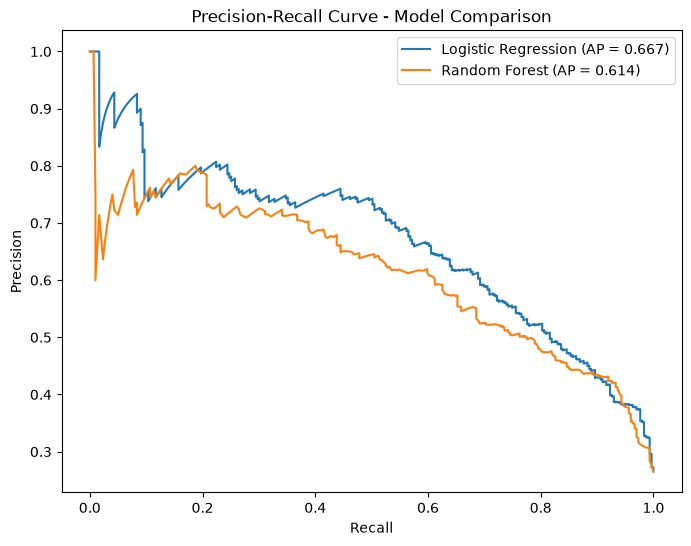

In [58]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Precision-Recall - LR
precision_model1, recall_model1, _ = precision_recall_curve(
    y_val,
    y_val_proba
)

ap_model1 = average_precision_score(
    y_val,
    y_val_proba
)

# Precision-Recall - RF
precision_model2, recall_model2, _ = precision_recall_curve(
    y_val,
    rf_val_proba
)

ap_model2 = average_precision_score(
    y_val,
    rf_val_proba
)

# Gráfico
plt.figure(figsize=(8, 6))

plt.plot(
    recall_model1,
    precision_model1,
    label=f"Logistic Regression (AP = {ap_model1:.3f})"
)

plt.plot(
    recall_model2,
    precision_model2,
    label=f"Random Forest (AP = {ap_model2:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Model Comparison")
plt.legend()
plt.show()

In [59]:
print(f"Logistic Regression - Average Precision: {ap_model1:.3f}")
print(f"Random Forest - Average Precision: {ap_model2:.3f}")

Logistic Regression - Average Precision: 0.667
Random Forest - Average Precision: 0.614


In [60]:
print("Logistic Regression:")
print(f"  ROC-AUC: {auc_model1:.3f}")
print(f"  Average Precision: {ap_model1:.3f}")

print("\nRandom Forest:")
print(f"  ROC-AUC: {auc_model2:.3f}")
print(f"  Average Precision: {ap_model2:.3f}")

Logistic Regression:
  ROC-AUC: 0.848
  Average Precision: 0.667

Random Forest:
  ROC-AUC: 0.827
  Average Precision: 0.614


### Model Selection

Logistic Regression was selected as the final model because it provided the strongest overall validation performance for the project's retention objective.

The comparison was performed using multiple metrics, with particular emphasis on **Recall and F1-score**, while also considering ROC-AUC and Average Precision.

Logistic Regression was evaluated using the optimized classification threshold selected during validation, while Random Forest was evaluated using its default threshold.

Given the objective of identifying as many potential churners as possible while maintaining a useful level of precision, Logistic Regression provided the most suitable balance between predictive performance and interpretability.
Logistic Regression was selected as the final model because it achieved better Recall, F1 Score, ROC-AUC, and Average Precision than Random Forest. This makes it more suitable for the business objective of identifying customers at risk of churn. Although Random Forest achieved slightly higher Accuracy and Precision, Logistic Regression detected more actual churners and produced fewer false negatives.

**Note:** Logistic Regression is evaluated using the optimized threshold selected on the validation set (0.38), while Random Forest is evaluated using the default threshold of 0.50. This reflects the final decision strategy adopted for the Logistic Regression model, where recall is prioritized for the churn-retention objective.


### Final Model

After selecting the classification threshold using the validation set, the final model is retrained using the complete training dataset.

The test set remains untouched and is used only for the final evaluation.

In [61]:
final_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

In [62]:
final_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [63]:
y_test_proba_final = final_model.predict_proba(X_test)[:, 1]

In [64]:
selected_threshold = best_result["Threshold"]

y_test_pred_final = (
    y_test_proba_final >= selected_threshold
).astype(int)

### Final Model Evaluation

The final model is evaluated on the held-out test set using the classification threshold selected from the validation set.

The test set is used only for final performance evaluation.

In [65]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print(f"Accuracy:  {accuracy_score(y_test, y_test_pred_final):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred_final):.4f}")
print(f"Recall:    {recall_score(y_test, y_test_pred_final):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_test_pred_final):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_test_proba_final):.4f}")

Accuracy:  0.7736
Precision: 0.5599
Recall:    0.6872
F1 Score:  0.6170
ROC-AUC:   0.8421


### Final Model - Confusion Matrix

The final confusion matrix shows how the selected threshold affects the classification of churn and non-churn customers on the held-out test set.

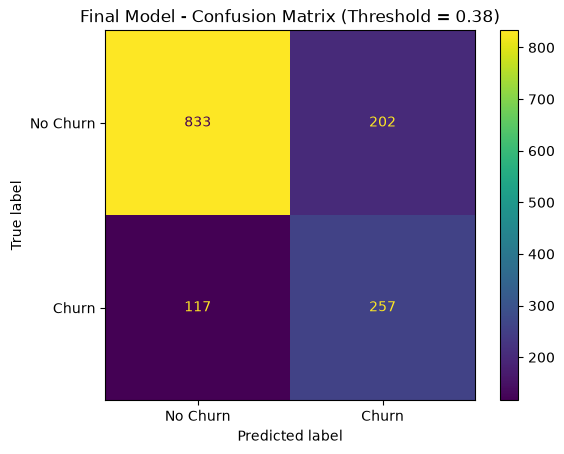

In [66]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_final = confusion_matrix(y_test, y_test_pred_final)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_final,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Final Model - Confusion Matrix (Threshold = 0.38)")
plt.show()

Lowering the classification threshold from 0.50 to 0.38 increased churn recall from 55.9% to 68.7%, allowing the model to identify 48 additional churners in the test set. This improvement came at the cost of 93 additional false positives.

## Model Interpretation

Because Logistic Regression is an interpretable linear model, its coefficients can be used to understand which features are associated with higher or lower predicted churn probability.

Categorical variables are interpreted through their one-hot encoded categories.

The final model provides not only predictions of customer churn, but also insights into the factors associated with higher or lower churn risk.

For the Logistic Regression model, the coefficients indicate the direction and relative strength of the relationship between each feature and the probability of churn, after preprocessing and encoding the categorical variables.

Positive coefficients are associated with a higher predicted churn risk, while negative coefficients are associated with a lower predicted churn risk.

These results should be interpreted as associations identified by the model rather than causal relationships.

In [67]:
feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()

coefficients = final_model.named_steps["model"].coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

feature_importance = feature_importance.sort_values(
    "Coefficient",
    ascending=False
)

feature_importance.head(10)

,Feature,Coefficient
16,cat__InternetService_Fiber optic,0.634195
36,cat__Contract_Month-to-month,0.582883
3,num__TotalCharges,0.536253
35,cat__StreamingMovies_Yes,0.200938
32,cat__StreamingTV_Yes,0.200481
43,cat__PaymentMethod_Electronic check,0.197867
18,cat__OnlineSecurity_No,0.156279
27,cat__TechSupport_No,0.131503
14,cat__MultipleLines_Yes,0.104649
0,num__SeniorCitizen,0.053449


In [68]:
feature_importance.sort_values(
    "Coefficient",
    ascending=True
).head(10)

,Feature,Coefficient
1,num__tenure,-1.257539
38,cat__Contract_Two year,-0.776594
15,cat__InternetService_DSL,-0.648646
2,num__MonthlyCharges,-0.591863
39,cat__PaperlessBilling_No,-0.343227
28,cat__TechSupport_No internet service,-0.300104
34,cat__StreamingMovies_No internet service,-0.300104
19,cat__OnlineSecurity_No internet service,-0.300104
25,cat__DeviceProtection_No internet service,-0.300104
31,cat__StreamingTV_No internet service,-0.300104


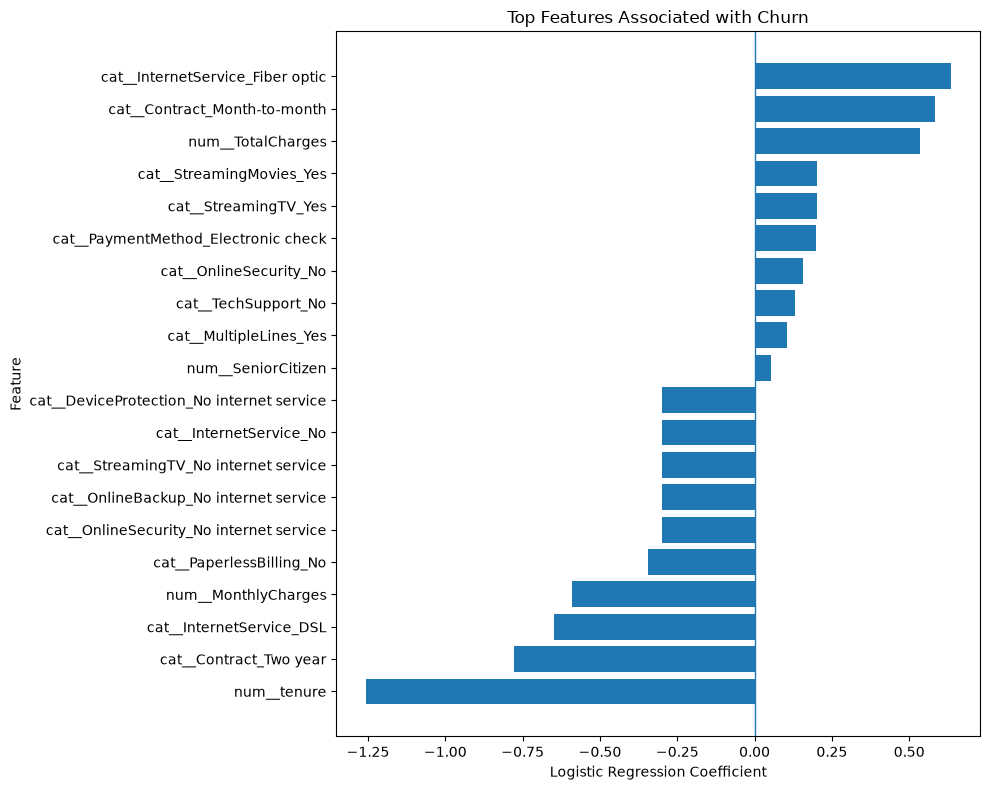

In [69]:
feature_importance_plot = pd.concat([
    feature_importance.head(10),
    feature_importance.tail(10)
]).sort_values("Coefficient")

plt.figure(figsize=(10, 8))

plt.barh(
    feature_importance_plot["Feature"],
    feature_importance_plot["Coefficient"]
)

plt.axvline(0, linewidth=1)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top Features Associated with Churn")

plt.tight_layout()
plt.show()

### Features Associated with Higher Churn Risk

The model identifies several features associated with a higher predicted probability of churn.

The strongest positive coefficients include:

* **InternetService_Fiber optic**: customers with fiber optic service show a higher predicted churn risk compared with the reference category.
* **Contract_Month-to-month**: month-to-month contracts are strongly associated with higher churn risk.
* **TotalCharges**: higher total charges are associated with higher predicted churn risk within the model.
* **StreamingMovies_Yes** and **StreamingTV_Yes**: customers subscribed to these services show moderately higher predicted churn risk.
* **PaymentMethod_Electronic check**: this payment method is associated with higher churn risk.
* **OnlineSecurity_No** and **TechSupport_No**: customers without these additional services show higher predicted churn risk.

Among these variables, **contract type and internet service are particularly important business signals**, as they were also identified during the exploratory analysis as being strongly associated with churn.


### Features Associated with Lower Churn Risk

Several features are associated with a lower predicted probability of churn.

The strongest negative coefficients include:

* **tenure**: customer tenure is the strongest negative coefficient, indicating that customers who have been with the company longer tend to have lower churn risk.
* **Contract_Two year**: customers with two-year contracts show substantially lower predicted churn risk compared with the reference contract category.
* **InternetService_DSL**: DSL customers show lower predicted churn risk compared with the reference category.
* **MonthlyCharges**: the model coefficient is negative after accounting for the other features included in the model.
* **PaperlessBilling_No**: customers who do not use paperless billing show lower predicted churn risk.

The strong negative coefficient for **tenure** is particularly relevant. It reinforces the EDA finding that churn is concentrated among newer customers, suggesting that the early stages of the customer lifecycle represent an important retention opportunity.


### Interpretation Summary

Overall, the model suggests that churn risk is strongly related to **customer tenure, contract type, internet service, and selected service and payment characteristics**.

The most relevant patterns are:

1. **Newer customers tend to have higher churn risk.**
2. **Month-to-month contracts are strongly associated with churn.**
3. **Fiber optic customers show higher predicted churn risk than DSL customers.**
4. **Customers without certain support and security services tend to have higher churn risk.**
5. **Payment method is also associated with different levels of churn risk.**

These findings provide a useful bridge between the predictive model and business decision-making. Rather than treating churn as a random event, the company can use these patterns to identify higher-risk customer segments and prioritize retention actions.

The next section translates these model findings into **business insights and actionable recommendations**.


## Business Insights and Recommendations

The analysis and model interpretation provide several actionable insights that can help the company better understand and manage customer churn.

### Business Insights

#### 1. Contract type is strongly associated with churn

Customers with **month-to-month contracts** show substantially higher churn rates than customers with one-year or two-year contracts. Conversely, the `Contract_Two year` feature has one of the strongest negative coefficients in the logistic regression model.

This suggests that contract duration is an important indicator when identifying customers at risk of churn.

#### 2. Customer tenure is a key retention indicator

`tenure` has the strongest negative coefficient in the model, indicating a strong association between customer longevity and lower churn risk.

The EDA also showed that customers in their first months with the company have considerably higher churn rates. This highlights the **early customer lifecycle** as an important period for retention efforts.

#### 3. Fiber optic customers represent a higher-risk segment

`InternetService_Fiber optic` is one of the strongest positive coefficients in the model. This is consistent with the EDA, which showed substantially higher churn rates among Fiber optic customers compared with DSL customers.

The model identifies Fiber optic customers as an important high-risk segment, although the model itself does not establish the underlying cause of this relationship.

#### 4. Additional services provide useful risk signals

Features such as `OnlineSecurity_No` and `TechSupport_No` are positively associated with churn.

This suggests that the presence or absence of additional services may help identify different customer risk profiles. However, these relationships should be interpreted as associations rather than evidence that adding these services will necessarily prevent churn.

---

### Business Recommendations

#### 1. Prioritize high-risk customers

The churn model can be used to identify customers with a high predicted probability of leaving and prioritize them for retention campaigns.

Instead of applying the same strategy to the entire customer base, the company could focus its resources on customers with the highest predicted risk.

#### 2. Focus on the early customer lifecycle

Given the strong relationship between `tenure` and churn, the company could implement targeted retention initiatives during the first months of the customer relationship.

Potential actions could include:

* Proactive onboarding follow-ups
* Customer satisfaction checks
* Early technical support
* Personalized offers for new customers
* Monitoring early signs of disengagement

#### 3. Encourage longer-term contracts

Since month-to-month customers present substantially higher churn rates, the company could test incentives to encourage customers to move toward one-year or two-year contracts.

Possible strategies include:

* Contract discounts
* Promotional pricing
* Bundled services
* Additional benefits for longer-term commitments

These strategies should ideally be evaluated through controlled experiments to determine whether they actually reduce churn.

#### 4. Investigate the high churn rate among Fiber optic customers

The model identifies Fiber optic customers as an important high-risk segment.

The company should therefore investigate potential underlying factors such as:

* Pricing
* Service quality
* Technical issues
* Customer expectations
* Competitive offers

The predictive model identifies **who is more likely to churn**, but it does not by itself explain **why they churn**. Additional analysis would be required to establish the underlying causes.

#### 5. Use the model as a decision-support tool

The model should not be viewed as a replacement for business judgment. Instead, it can support a continuous retention process:

**Predict → Prioritize → Intervene → Measure → Improve**

Customer risk predictions can be combined with customer value and business context to determine which retention actions should be prioritized.

The effectiveness of these interventions should then be measured over time and used to improve future retention strategies.

---

### Key Takeaway

The analysis suggests that churn is particularly associated with **short-term contracts, low customer tenure, and Fiber optic service**, while longer tenure and longer-term contracts are associated with lower churn risk.

The main business opportunity is therefore not simply to predict which customers will churn, but to use those predictions to **prioritize retention efforts, focus on vulnerable customer segments, and evaluate whether targeted interventions actually improve retention**.

> **Important:** The relationships identified in this project represent statistical associations and should not be interpreted as causal effects.


## Project Conclusion

This project developed an end-to-end machine learning workflow to predict customer churn using the IBM Telco Customer Churn dataset.

The analysis began with exploratory data analysis, which identified several patterns associated with customer churn. In particular, **month-to-month contracts, lower customer tenure, and Fiber optic service** were associated with higher churn rates.

Several preprocessing and modeling steps were then implemented to prepare the data and evaluate different machine learning approaches. Logistic Regression was used as an interpretable baseline, while a non-linear model was evaluated to determine whether more complex relationships could improve predictive performance.

Model evaluation focused not only on accuracy, but also on **precision, recall, F1-score, and ROC-AUC**, with particular attention to recall because identifying customers who are likely to churn is an important business objective.

The final modeling stage also included **threshold optimization**, demonstrating that the default classification threshold is not necessarily the most appropriate choice for a business problem. Adjusting the threshold allowed the model to achieve a better balance between precision and recall according to the project's retention objective.

Feature interpretation provided additional business insights. The model identified **tenure and contract type** as particularly important predictors, while Fiber optic service was strongly associated with increased churn risk.

The main business application of the model is therefore not simply to predict churn, but to **prioritize customers for targeted retention efforts**. A company could use these predictions to focus its resources on high-risk customers, particularly those with combinations of characteristics associated with elevated churn.

Finally, the results should be interpreted as **statistical associations rather than causal relationships**. The model can identify customers who are more likely to churn, but additional experimentation and business analysis would be required to determine which interventions are most effective at preventing churn.

### Final Takeaway

> **A churn prediction model becomes valuable when its predictions can support better business decisions. In this project, machine learning was used not only to predict customer churn, but also to identify high-risk customer profiles and translate those predictions into actionable retention strategies.**
